In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
def sigmoid(x):
     return 1 / (1 + np.exp(-x))

In [17]:
def sigmoid_derivative(x): 
    return x * (1 - x) 
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]) 
y = np.array([[0], [0], [0], [1]]) 
input_neurons = X.shape[1]  
hidden_neurons = 2 
output_neurons = 1 
np.random.seed(1) 
  
weights_input_hidden = np.random.rand(input_neurons, hidden_neurons) 
bias_hidden = np.random.rand(hidden_neurons) 
weights_hidden_output = np.random.rand(hidden_neurons, output_neurons) 
bias_output = np.random.rand(output_neurons) 
learning_rate = 0.1 
epochs = 10000 
errors = [] 

for epoch in range(epochs): 
  
    hidden_layer_input = np.dot(X, weights_input_hidden) + bias_hidden 
    hidden_layer_output = sigmoid(hidden_layer_input) 
    final_input = np.dot(hidden_layer_output, weights_hidden_output) + bias_output 
    final_output = sigmoid(final_input) 
    error = y - final_output 
    errors.append(np.mean(np.abs(error))) 
    d_output = error * sigmoid_derivative(final_output)
    d_hidden_layer = np.dot(d_output, weights_hidden_output.T) * sigmoid_derivative(hidden_layer_output)

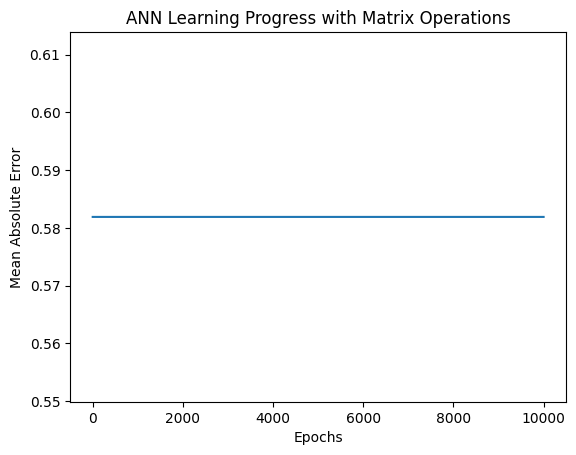

In [18]:


 # Update weights and biases using matrix operations
 weights_hidden_output += np.dot(hidden_layer_output.T, d_output) * learning_rate
 bias_output += np.sum(d_output, axis=0) * learning_rate
 weights_input_hidden += np.dot(X.T, d_hidden_layer) * learning_rate
 bias_hidden += np.sum(d_hidden_layer, axis=0) * learning_rate

# Plot error reduction over epochs
plt.plot(errors)
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.title('ANN Learning Progress with Matrix Operations')
plt.show()